In [1]:
print("Hello")

Hello


In [36]:
pip install beautifulsoup4 requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/ecommerce_data.csv")

df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [4]:


df.shape


(20000, 15)

In [5]:
df.columns

Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  str    
 1   crawl_timestamp          20000 non-null  str    
 2   product_url              20000 non-null  str    
 3   product_name             20000 non-null  str    
 4   product_category_tree    20000 non-null  str    
 5   pid                      20000 non-null  str    
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  str    
 9   is_FK_Advantage_product  20000 non-null  bool   
 10  description              19998 non-null  str    
 11  product_rating           20000 non-null  str    
 12  overall_rating           20000 non-null  str    
 13  brand                    14136 non-null  str    
 14  product_specifications   19986 no

Check Missing Values

In [7]:
df.isnull().sum()

uniq_id                       0
crawl_timestamp               0
product_url                   0
product_name                  0
product_category_tree         0
pid                           0
retail_price                 78
discounted_price             78
image                         3
is_FK_Advantage_product       0
description                   2
product_rating                0
overall_rating                0
brand                      5864
product_specifications       14
dtype: int64

Remove Missing Values (Data Cleaning)

In [8]:
df = df.dropna()

Check Dataset Again

In [9]:
df.isnull().sum()

uniq_id                    0
crawl_timestamp            0
product_url                0
product_name               0
product_category_tree      0
pid                        0
retail_price               0
discounted_price           0
image                      0
is_FK_Advantage_product    0
description                0
product_rating             0
overall_rating             0
brand                      0
product_specifications     0
dtype: int64

Check Dataset Size After Cleaning

In [10]:
df.shape

(14058, 15)

Clean Price Columns

In [11]:
df[["retail_price", "discounted_price"]].dtypes

retail_price        float64
discounted_price    float64
dtype: object

In [13]:


df["retail_price"] = pd.to_numeric(
    df["retail_price"],
    errors="coerce"
)

df["discounted_price"] = pd.to_numeric(
    df["discounted_price"],
    errors="coerce"
)

In [14]:
df[["retail_price", "discounted_price"]].dtypes

retail_price        float64
discounted_price    float64
dtype: object

Check Product Ratings Properly


In [15]:
df["product_rating"].unique()

<StringArray>
['No rating available',                   '5',                 '3.6',
                   '3',                   '4',                 '2.4',
                 '3.3',                   '1',                 '3.8',
                 '3.2',                 '3.5',                 '3.7',
                 '2.3',                   '2',                 '3.9',
                 '2.5',                 '2.7',                 '4.5',
                 '4.7',                 '4.1',                 '4.4',
                 '4.3',                 '3.4',                 '4.6',
                 '4.2',                 '1.5',                 '2.8',
                 '2.9',                 '4.9',                 '4.8',
                 '2.2',                 '1.3',                 '1.7',
                 '1.8',                 '3.1',                 '2.6']
Length: 36, dtype: str

. Remove Invalid Ratings

In [16]:
df = df[df["product_rating"] != "No rating available"]

Convert Ratings to Numeric

In [17]:
df["product_rating"] = pd.to_numeric(
    df["product_rating"],
    errors="coerce"
)

In [18]:
df["product_rating"].dtype

dtype('float64')

In [19]:
df.to_csv(
    "../data/cleaned_ecommerce_data.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


Exploratory Data Analysis (EDA)

In [20]:
clean_df = pd.read_csv("../data/cleaned_ecommerce_data.csv")

clean_df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,e54bc0a7c3429da2ebef0b30331fe3d2,2016-03-25 22:59:23 +0000,http://www.flipkart.com/ladela-bellies/p/itmeh...,Ladela Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4KM2W3Z6EH5,1724.0,950.0,"[""http://img5a.flixcart.com/image/shoe/s/g/m/b...",False,Key Features of Ladela Bellies Brand: LADELA C...,5.0,5.0,Ladela,"{""product_specification""=>[{""key""=>""Occasion"",..."
1,d620fa0d35825bb3c0717e9d3446cc97,2016-04-05 17:56:58 +0000,http://www.flipkart.com/roadster-men-s-zipper-...,Roadster Men's Zipper Solid Cardigan,"[""Clothing >> Men's Clothing >> Winter & Seaso...",CGNEDFY77SGZTEQ2,1399.0,699.0,"[""http://img5a.flixcart.com/image/cardigan/e/q...",False,Key Features of Roadster Men's Zipper Solid Ca...,3.6,3.6,Roadster,"{""product_specification""=>[{""key""=>""Closure"", ..."
2,7ebca8e1830a1a7041f77c342b1282ee,2015-12-04 07:25:36 +0000,http://www.flipkart.com/roadster-skinny-fit-me...,Roadster Skinny Fit Fit Men's Jeans,"[""Clothing >> Men's Clothing >> Jeans >> Roads...",JEAE8CZGJ8PGGHRQ,2499.0,1249.0,"[""http://img5a.flixcart.com/image/jean/g/b/h/7...",True,Roadster Skinny Fit Fit Men's Jeans - Buy MD I...,3.0,3.0,Skinny Fit,"{""product_specification""=>[{""key""=>""Number of ..."
3,4889f91f48c3e1260a8fb3b3b83fe6f2,2016-01-06 18:20:45 +0000,http://www.flipkart.com/pure-source-psi-as-han...,Pure Source Psi-As-Hanggnrlx Relaxing Liquid A...,"[""Home Decor & Festive Needs >> Candles & Frag...",AIRE9B8EKTNR8J4B,1250.0,375.0,"[""http://img6a.flixcart.com/image/air-freshene...",False,Buy Pure Source Psi-As-Hanggnrlx Relaxing Liqu...,5.0,5.0,Pure Source,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,465662da5f4b41c475d51684084f59c7,2016-01-06 18:20:45 +0000,http://www.flipkart.com/clara-certified-katela...,Clara Certified Katela 3 cts or 3.25 ratti 4 P...,"[""Jewellery >> Rings""]",RNGEFP2XZSFFAGGV,3530.0,1570.0,"[""http://img6a.flixcart.com/image/ring/v/b/y/c...",False,Clara Certified Katela 3 cts or 3.25 ratti 4 P...,4.0,4.0,Clara,"{""product_specification""=>[{""key""=>""Sales Pack..."


Graph — Rating Distribution

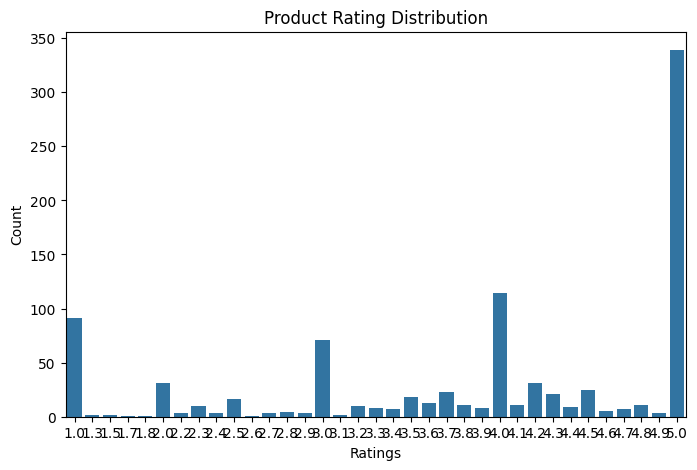

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x=clean_df["product_rating"])

plt.title("Product Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()

Price Distribution Graph

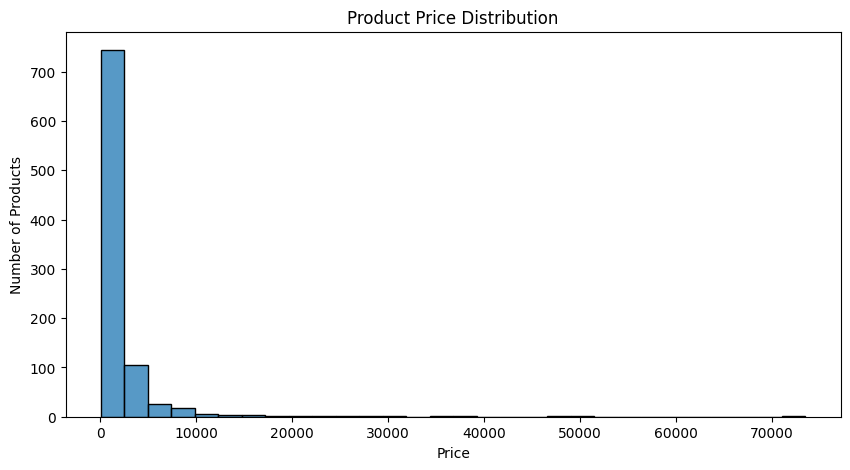

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    clean_df["retail_price"],
    bins=30
)

plt.title("Product Price Distribution")

plt.xlabel("Price")

plt.ylabel("Number of Products")

plt.show()

Top Product Categories Analysis

In [23]:
top_categories = clean_df["product_category_tree"].value_counts().head(10)

top_categories

product_category_tree
["Jewellery >> Necklaces & Chains >> Necklaces"]                                                       68
["Tools & Hardware >> Tools >> Gardening Tools >> Plant Containers & Sets >> Plant Container Sets"]    42
["Jewellery >> Bangles, Bracelets & Armlets >> Bangles"]                                               39
["Home Furnishing >> Bath Linen >> Towels"]                                                            21
["Computers >> Network Components >> Routers >> Tenda Routers"]                                        19
["Computers >> Network Components >> Routers >> Asus Routers"]                                         19
["Computers >> Network Components >> Routers >> TP-LINK Routers"]                                      19
["Computers >> Network Components >> Routers >> Netgear Routers"]                                      16
["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Bras >> Ladyland Bras"]                13
["Clothing >> Women's Cl

 Bar Chart Top Product Categories Analysis

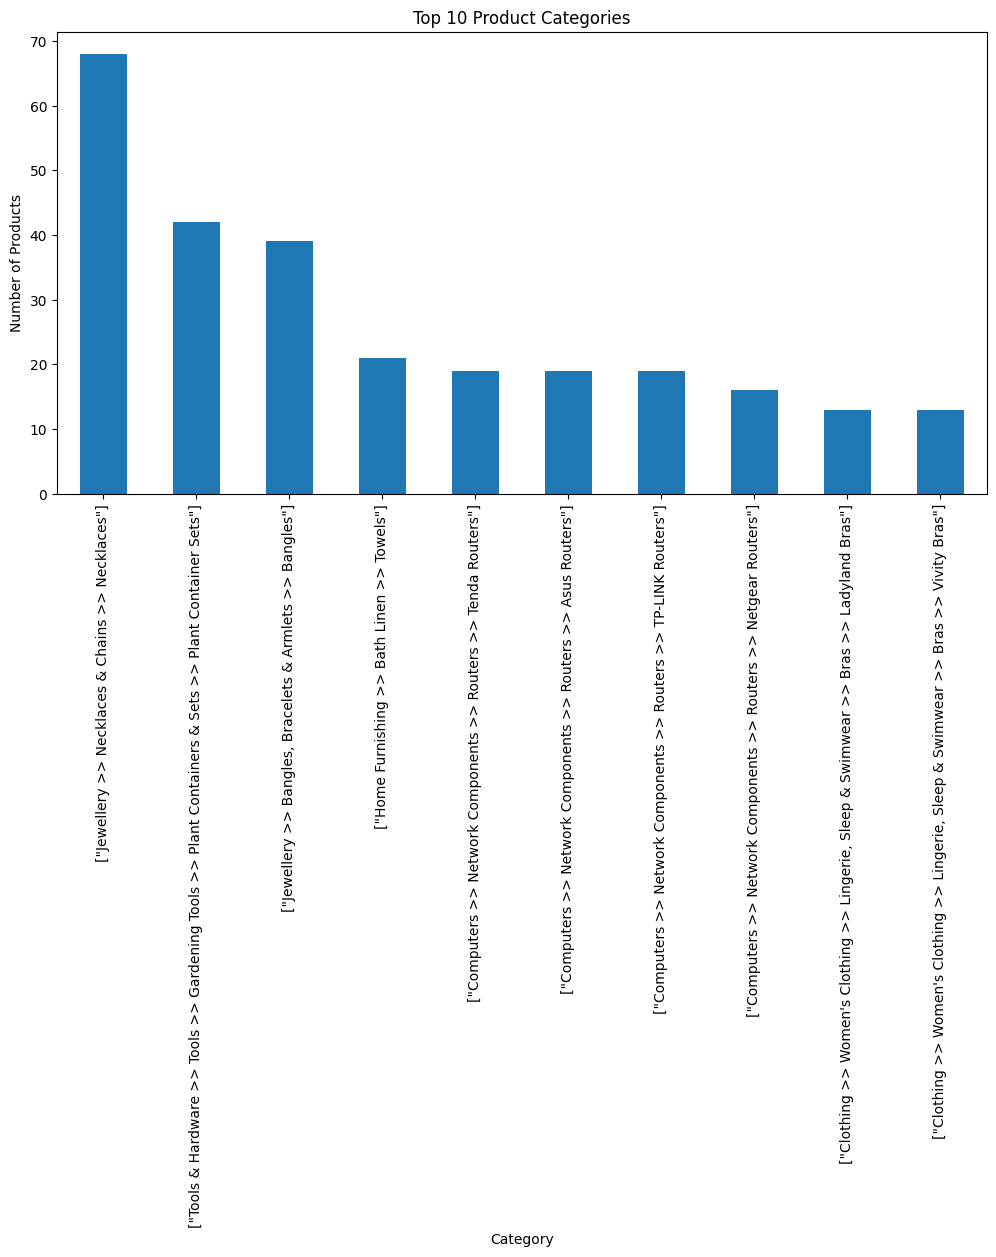

In [24]:
plt.figure(figsize=(12,6))

top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories")

plt.xlabel("Category")

plt.ylabel("Number of Products")

plt.xticks(rotation=90)

plt.show()

Price vs Rating Analysis

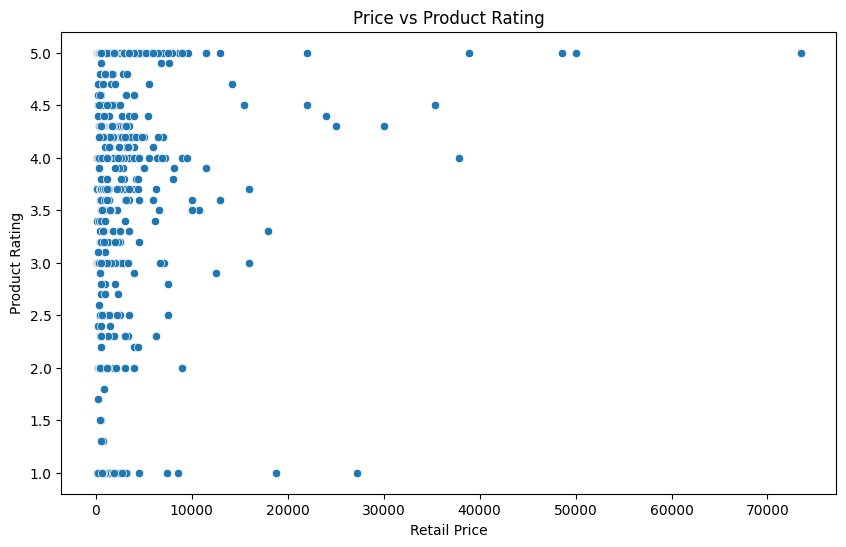

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=clean_df["retail_price"],
    y=clean_df["product_rating"]
)

plt.title("Price vs Product Rating")

plt.xlabel("Retail Price")

plt.ylabel("Product Rating")

plt.show()

insight
1. Product ratings vary across different price ranges.
2. Higher price does not always guarantee better ratings.
3. Some low-priced products also receive high customer ratings.

Find Top Rated Products

In [26]:
top_rated = clean_df.sort_values(
    by="product_rating",
    ascending=False
)

top_rated[[
    "product_name",
    "brand",
    "product_rating",
    "retail_price"
]].head(10)

,product_name,brand,product_rating,retail_price
5,Nishtaa Yellow Gold 22 K Ring,Nishtaa,5.0,7810.0
6,"Imported Banknote Tester, ball pen Permanent A...",Imported,5.0,800.0
0,Ladela Bellies,Ladela,5.0,1724.0
8,INDIANO Loafers,INDIANO,5.0,1199.0
914,MUA MAKEUP ACADEMY SWEET SHEEN DUSKY ROSE,MUA MAKEUP ACADEMY,5.0,550.0
614,Aimeon Women's Solid Casual Shirt,Regular,5.0,1040.0
621,Kashana Fashions Women's Printed Casual Shirt,Regular,5.0,1899.0
622,Vedika Jewellery Alloy Bangle Set,Vedika Jewellery,5.0,1299.0
625,"StylElite Women's Solid Casual, Formal Shirt",Regular,5.0,599.0
627,Eves Pret A Porter Women's Printed Casual Shirt,Regular,5.0,1300.0


Visualization

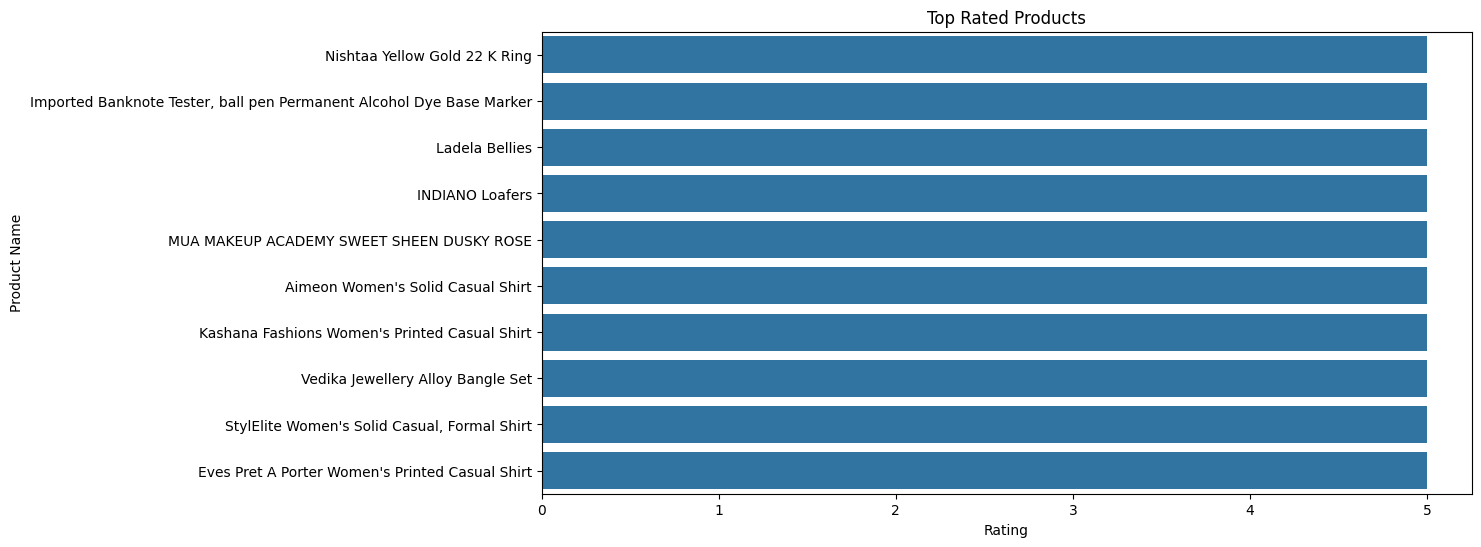

In [27]:
top10 = top_rated.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10["product_rating"],
    y=top10["product_name"]
)

plt.title("Top Rated Products")

plt.xlabel("Rating")

plt.ylabel("Product Name")

plt.show()

INSIGHTS
1. Several products received very high customer ratings.
2. Highly rated products belong to different brands and categories.
3. Customer satisfaction varies significantly across products.

Brand Analysis: to find Find Top Brands


In [28]:
top_brands = clean_df["brand"].value_counts().head(10)

top_brands

brand
Regular    56
Slim       34
Clovia     24
Tenda      19
Asus       19
TP-LINK    19
Black      17
Netgear    16
Red        13
White      13
Name: count, dtype: int64

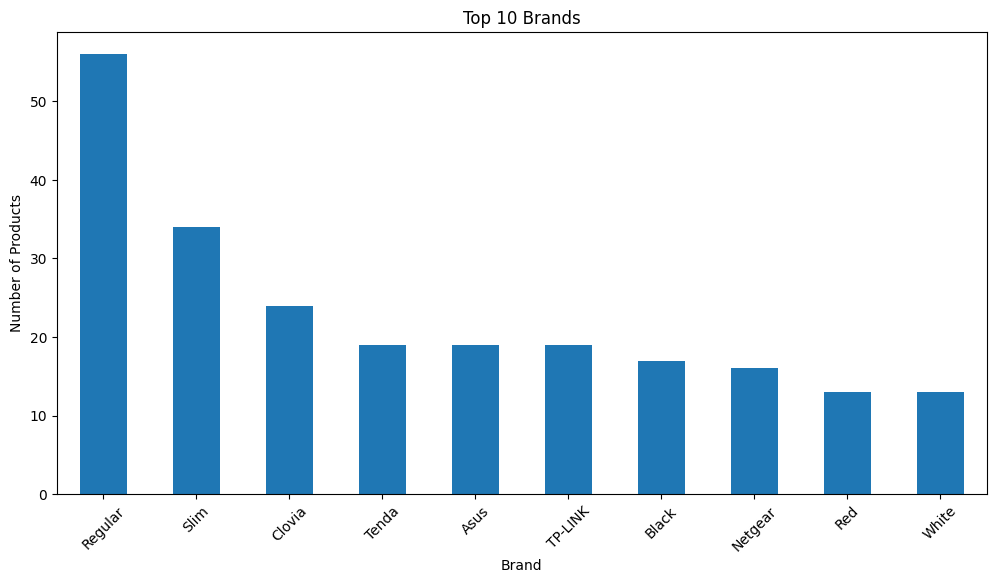

In [29]:
plt.figure(figsize=(12,6))

top_brands.plot(kind="bar")

plt.title("Top 10 Brands")

plt.xlabel("Brand")

plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

INSIGHTS
1. Certain brands dominate the e-commerce platform.
2. Popular brands have a larger number of listed products.
3. Brand presence varies significantly across the dataset.